# 04 — O2 : sécurité routière

Ce notebook **visualise** les données qui alimentent les indicateurs de O2. Il ne produit aucun chiffre du 04 : la faisabilité vient de `faisabilite_indicateurs.csv` (`scripts/faisabilite_04.py`), les contrôles de `controles_coherence.csv` et `jointures.csv` (R-19). Aucune lecture causale.

**Ce qu'on regarde** : la série nationale des accidents constatés, des tués et des blessés (2010–2024), le repère de l'OMS et la répartition des tués par type d'usager (2021). Les accidents n'ont aucune variable territoriale (écart 1).

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
from IPython.display import display
from style_04 import *
appliquer_style()
pd.set_option("display.max_colwidth", 90)

## Faisabilité des 14 indicateurs

In [2]:
display(faisabilite("O2"))

,Indicateur,Prévu (03),Résultat (04),Maille obtenue,Période,Preuve (04),Réserve
ID,,,,,,,
O2-01,"Accidents corporels, blessés, tués",Repli : national,Repli,National,2010–2024,A,Libellé « accidents constatés »
O2-02,Tués pour 100 000 habitants,Repli : national,Repli,National,2010–2024,"B en 2010 et 2022, C les autres années",
O2-03,Accidents corporels pour 100 000 habitants,Repli : national,Repli,National,2010–2024,"B en 2010 et 2022, C les autres années",Libellé « accidents constatés »
O2-04,Tués pour 10 000 véhicules,Cible (national),Cible,National,2010–2024,C,
O2-05,Tués pour 100 accidents corporels,Repli : national,Repli,National,2010–2024,B,Accidents constatés (écart 15)
O2-06,Blessés pour 100 accidents corporels,Repli : national,Repli,National,2010–2024,B,Accidents constatés (écart 15)
O2-07,Accidents par catégorie de véhicule impliqué,Non,Non,—,,—,
O2-08,Surreprésentation d’une catégorie,Non,Non,—,,—,
O2-09,"Victimes par type d’usager, sexe et âge","Repli : type d’usager, 2021 (OMS)",Repli,"National, type d'usager",2021,C,


## Accidents constatés, blessés et tués

Deux panneaux, car les tués sont dix fois moins nombreux : un seul axe par graphique. Statistiques clés jusqu'en 2022, annuaire 2024 ensuite (séries identiques sur leurs années communes, contrôle 4.4-05). Le repère de l'OMS est une estimation modélisée (C), jamais une correction (SE-03).

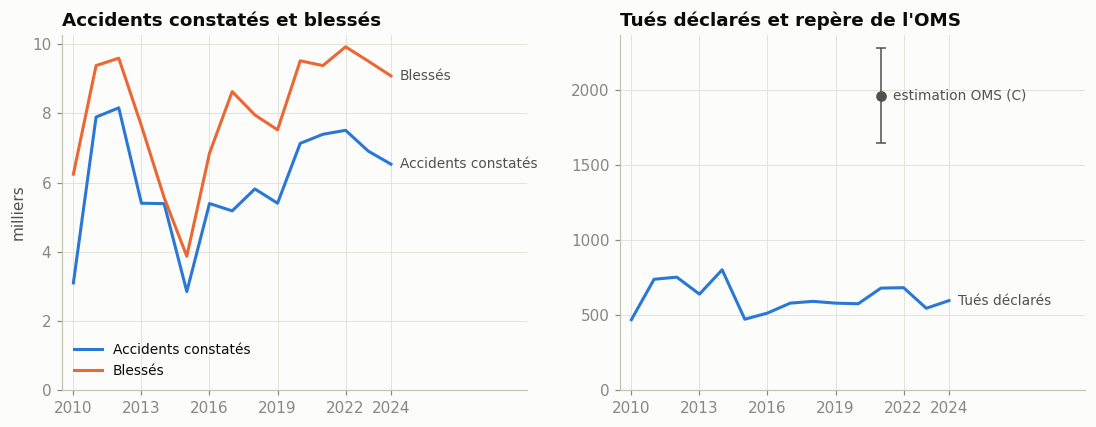

,Accidents constatés,Blessés,Tués
2010,3101,6241,470
2011,7889,9376,739
2012,8155,9589,753
2013,5401,7636,640
2014,5390,5565,802
2015,2851,3871,473
2016,5393,6846,514
2017,5181,8624,580
2018,5814,7951,592
2019,5402,7520,580


In [3]:
c = portail("transports_statistiques_cles.csv")
noms = {"Nombre de cas d'accidents de la circulation": "Accidents constatés", "Nombre de blessés": "Blessés", "Nombre de morts": "Tués"}
serie = c[c["indicateur"].isin(noms)].assign(cle=lambda d: d["indicateur"].map(noms)).pivot(index="Date", columns="cle", values="Value")
a = annuaire("7.2").pivot(index="Année", columns="Ligne", values="Valeur").rename(columns={"Nombre d’accidents": "Accidents constatés", "Nombre de blesses": "Blessés", "Nombre de morts": "Tués"})
serie = pd.concat([serie, a[a.index > serie.index.max()]])
oms = pd.read_csv(INTERIM / "oms_profil_2023.csv")
estime = oms[oms["Indicateur"] == "Tués estimés par l’OMS"].set_index("Modalité")["Valeur"]
an_oms = int(oms[oms["Indicateur"] == "Tués estimés par l’OMS"]["Année"].iloc[0])
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
for couleur, cat in zip(SERIES, ["Accidents constatés", "Blessés"]):
    ax1.plot(serie.index, serie[cat] / 1000, color=couleur, label=cat)
ax1.set_ylim(0); ax1.set_xlim(2009.5, 2030); ax1.set_xticks([2010, 2013, 2016, 2019, 2022, 2024])
etiquettes_fin(ax1, serie.index[-1], {cat: serie[cat].iloc[-1] / 1000 for cat in ["Accidents constatés", "Blessés"]})
ax1.set_ylabel("milliers"); ax1.set_title("Accidents constatés et blessés"); ax1.legend(fontsize=9, loc="lower left")
ax2.plot(serie.index, serie["Tués"], color=SERIES[0], label="Tués déclarés")
ax2.errorbar([an_oms], [estime["valeur centrale"]], yerr=[[estime["valeur centrale"] - estime["borne basse"]], [estime["borne haute"] - estime["valeur centrale"]]],
             fmt="o", color=ENCRE_2, markersize=6, capsize=3, linewidth=1)
ax2.annotate("estimation OMS (C)", (an_oms, estime["valeur centrale"]), xytext=(8, 0), textcoords="offset points", va="center", fontsize=9, color=ENCRE_2)
ax2.set_ylim(0); ax2.set_title("Tués déclarés et repère de l'OMS")
etiquettes_fin(ax2, serie.index[-1], {"Tués déclarés": serie["Tués"].iloc[-1]})
plt.show()
display(serie.astype("Int64"))

## Tués déclarés par type d'usager (OMS, 2021)

Seul découpage disponible (écart 3) : sans sexe ni âge, en C.

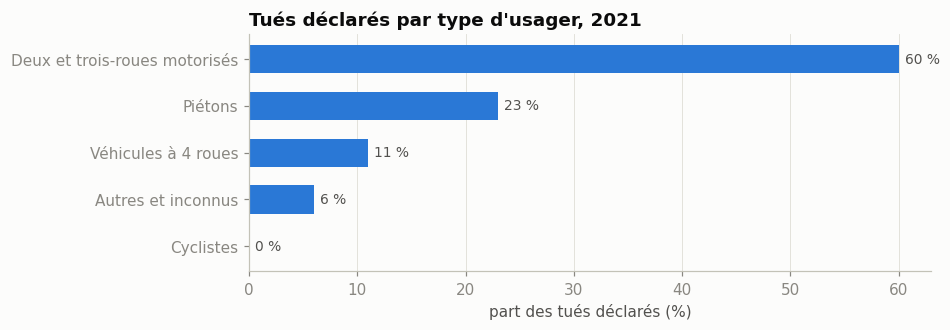

,Part (%)
Modalité,
Cyclistes,0.0
Autres et inconnus,6.0
Véhicules à 4 roues,11.0
Piétons,23.0
Deux et trois-roues motorisés,60.0


In [4]:
u = oms[oms["Indicateur"].str.startswith("Répartition")].set_index("Modalité")["Valeur"].sort_values()
fig, ax = plt.subplots(figsize=(8, 2.8))
ax.barh(u.index, u.values, color=SERIES[0], height=0.6)
for y, v in enumerate(u.values):
    ax.annotate(f"{v:.0f} %", (v, y), xytext=(4, 0), textcoords="offset points", va="center", fontsize=9, color=ENCRE_2)
ax.set_xlabel("part des tués déclarés (%)"); ax.set_title("Tués déclarés par type d'usager, 2021"); ax.grid(axis="y", visible=False)
plt.show()
display(u.to_frame("Part (%)"))